# Project EDA

## By: Cyrus Sobhani

## Step 1: Import packages

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Import Data and Create Column Name Dictionary

In [141]:
# Google anaytics
GoogleAnalytics = pd.read_csv("google_analytics.csv")
# orders
orders = pd.read_csv("orders.csv")
# sales 
sales = pd.read_csv("sales.csv")
# material
material = pd.read_csv("material.csv")
# customer
customer = pd.read_csv("customer.csv")
# custoff_times
cutoff_times = pd.read_csv("cutoff_times.csv")
# operating hours
operating_hours = pd.read_csv("operating_hours.csv")
# visit plan
visit_plan = pd.read_csv("visit_plan.csv", low_memory=False)

In [142]:
ColumnNames = {
    "GoogleAnalytics": GoogleAnalytics.columns.tolist(),
    "orders": orders.columns.tolist(),
    "sales": sales.columns.tolist(),
    "material": material.columns.tolist(),
    "customer": customer.columns.tolist(),
    "cutoff_times": cutoff_times.columns.tolist(),
    "operating_hours": operating_hours.columns.tolist(),
    "visit_plan": visit_plan.columns.tolist()
}

for key in ColumnNames:
    print(f"DataFrame: {key}")
    print(ColumnNames[key])

DataFrame: GoogleAnalytics
['CUSTOMER_ID', 'EVENT_DATE', 'EVENT_TIMESTAMP', 'EVENT_NAME', 'DEVICE_CATEGORY', 'DEVICE_MOBILE_BRAND_NAME', 'DEVICE_OPERATING_SYSTEM', 'EVENT_PAGE_NAME', 'EVENT_PAGE_TITLE', 'ITEMS']
DataFrame: orders
['CUSTOMER_ID', 'CREATED_DATE_EST', 'CREATED_DATE_UTC', 'MATERIAL_ID', 'ORDER_QUANTITY', 'ORDER_TYPE', 'PLANT_ID']
DataFrame: sales
['CUSTOMER_ID', 'POSTING_DATE', 'MATERIAL_ID', 'GROSS_PROFIT_DEAD_NET', 'PHYSICAL_VOLUME', 'NSI_DEAD_NET']
DataFrame: material
['MATERIAL_ID', 'PACK_TYPE_DESC', 'TRADE_MARK_DESC', 'FLAVOUR_DESC', 'PACK_SIZE_DESC', 'BEV_CAT_DESC']
DataFrame: customer
['SALES_OFFICE', 'CUSTOMER_NUMBER', 'SALES_OFFICE_DESCRIPTION', 'DISTRIBUTION_MODE_DESCRIPTION', 'SHIPPING_CONDITIONS_DESCRIPTION', 'COLD_DRINK_CHANNEL_DESCRIPTION', 'CUSTOMER_SUB_TRADE_CHANNEL_DESCRIPTION']
DataFrame: cutoff_times
['SALES_OFFICE', 'PLANT_ID', 'CUTOFFTIME__C', 'SHIPPING_CONDITION_TIME', 'DISTRIBUTION_MODE']
DataFrame: operating_hours
['CUSTOMER_NUMBER', 'FREQUENCY', 'D

Looking at the Dictionary output above. Joins for the following dataframes will be done on these columns:

CUSTOMER_ID / CUSTOMER_NUMBER:
1. google_analytics
2. orders
3. sales
4. customer 
5. operating_hours
6. visit_plan

MATERIAL_ID:
1. sales
2. material

## Step 3: Explore Each Table

What sections do we want to do for the EDA:
1. Areas where data is missing
2. Data sparsity for dimensionality reduction and materiality
3. Visualizations for times and sparsity
4. Quick write-ups for each table detailing dimensionality reduction 

Split each section by the table we are analyzing

### Google Analytics

In [147]:
GoogleAnalytics.head(n=5)

,CUSTOMER_ID,EVENT_DATE,EVENT_TIMESTAMP,EVENT_NAME,DEVICE_CATEGORY,DEVICE_MOBILE_BRAND_NAME,DEVICE_OPERATING_SYSTEM,EVENT_PAGE_NAME,EVENT_PAGE_TITLE,ITEMS
0,501508595,2025-04-07,2025-04-07T14:57:40.713Z,view_search_results,mobile,Samsung,Android,Product List,NaN,[]
1,501730915,2025-04-07,2025-04-07T19:28:54.546Z,view_item_list,desktop,Google,Windows,NaN,Search,"[{""item_id"":""158520"",""quantity"":""1""},{""item_id..."
2,501567329,2025-04-07,2025-04-07T21:40:56.281Z,purchase,desktop,Google,Windows,MyCoke Orders - Purchase Success,Order,"[{""item_id"":""138335"",""quantity"":""2""},{""item_id..."
3,501765083,2025-04-08,2025-04-08T06:06:36.717Z,user_engagement,mobile,Apple,iOS,NaN,NaN,[]
4,501707837,2025-04-08,2025-04-08T18:12:10.511Z,view_item_list,desktop,Google,Windows,MyCoke Orders,Category: All Products,"[{""item_id"":""412588"",""quantity"":""1""},{""item_id..."


In [148]:
print("There are",GoogleAnalytics.index.size,"rows in the dataframe.")
print("There are",GoogleAnalytics.columns.size,"columns in the dataframe.")

There are 3704088 rows in the dataframe.
There are 10 columns in the dataframe.


In [149]:
GoogleAnalytics.dtypes

CUSTOMER_ID                  int64
EVENT_DATE                  object
EVENT_TIMESTAMP             object
EVENT_NAME                  object
DEVICE_CATEGORY             object
DEVICE_MOBILE_BRAND_NAME    object
DEVICE_OPERATING_SYSTEM     object
EVENT_PAGE_NAME             object
EVENT_PAGE_TITLE            object
ITEMS                       object
dtype: object

It looks like we need to convert a few columns into their proper datatypes. Following columns that should be converted:

1. EVENT_DATE -> date
2. EVENT_TIMESTAMP -> datetime
3. EVENT_NAME -> string
4. DEVICE_CATEGORY -> string
5. DEVICE_MOBILE_BRAND_NAME -> string
6. DEVICE_OPERATING_SYSTEM -> string
7. EVENT_PAGE_NAME -> string
8. EVENT_PAGE_TITLE -> string
9. ITEMS -> list

In [151]:
# Convert the strings

GoogleAnalytics['EVENT_NAME'] = GoogleAnalytics['EVENT_NAME'].astype(str)
GoogleAnalytics['DEVICE_CATEGORY'] = GoogleAnalytics['DEVICE_CATEGORY'].astype(str)
GoogleAnalytics['DEVICE_MOBILE_BRAND_NAME'] = GoogleAnalytics['DEVICE_MOBILE_BRAND_NAME'].astype(str)
GoogleAnalytics['DEVICE_OPERATING_SYSTEM'] = GoogleAnalytics['DEVICE_OPERATING_SYSTEM'].astype(str)
GoogleAnalytics['EVENT_PAGE_NAME'] = GoogleAnalytics['EVENT_PAGE_NAME'].astype(str)
GoogleAnalytics['EVENT_PAGE_TITLE'] = GoogleAnalytics['EVENT_PAGE_TITLE'].astype(str)

# Check
print(GoogleAnalytics.dtypes)

CUSTOMER_ID                  int64
EVENT_DATE                  object
EVENT_TIMESTAMP             object
EVENT_NAME                  object
DEVICE_CATEGORY             object
DEVICE_MOBILE_BRAND_NAME    object
DEVICE_OPERATING_SYSTEM     object
EVENT_PAGE_NAME             object
EVENT_PAGE_TITLE            object
ITEMS                       object
dtype: object


In [152]:
# Convert the date/datetime(s)

GoogleAnalytics['EVENT_DATE'] = pd.to_datetime(GoogleAnalytics['EVENT_DATE'])
GoogleAnalytics['EVENT_TIMESTAMP'] = pd.to_datetime(GoogleAnalytics['EVENT_TIMESTAMP'])

# Check
print(GoogleAnalytics.dtypes)

CUSTOMER_ID                               int64
EVENT_DATE                       datetime64[ns]
EVENT_TIMESTAMP             datetime64[ns, UTC]
EVENT_NAME                               object
DEVICE_CATEGORY                          object
DEVICE_MOBILE_BRAND_NAME                 object
DEVICE_OPERATING_SYSTEM                  object
EVENT_PAGE_NAME                          object
EVENT_PAGE_TITLE                         object
ITEMS                                    object
dtype: object


In [153]:
# Convert the list

GoogleAnalytics['ITEMS'] = GoogleAnalytics['ITEMS'].tolist()

# Check
print(GoogleAnalytics.dtypes)

CUSTOMER_ID                               int64
EVENT_DATE                       datetime64[ns]
EVENT_TIMESTAMP             datetime64[ns, UTC]
EVENT_NAME                               object
DEVICE_CATEGORY                          object
DEVICE_MOBILE_BRAND_NAME                 object
DEVICE_OPERATING_SYSTEM                  object
EVENT_PAGE_NAME                          object
EVENT_PAGE_TITLE                         object
ITEMS                                    object
dtype: object


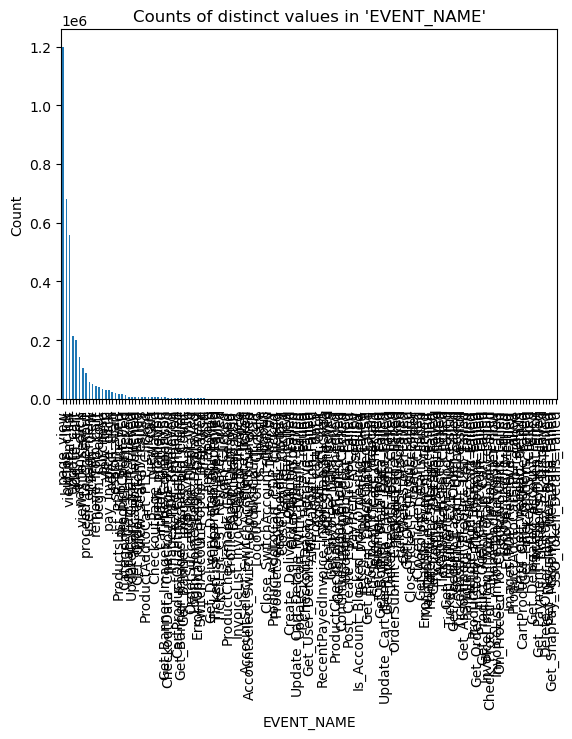

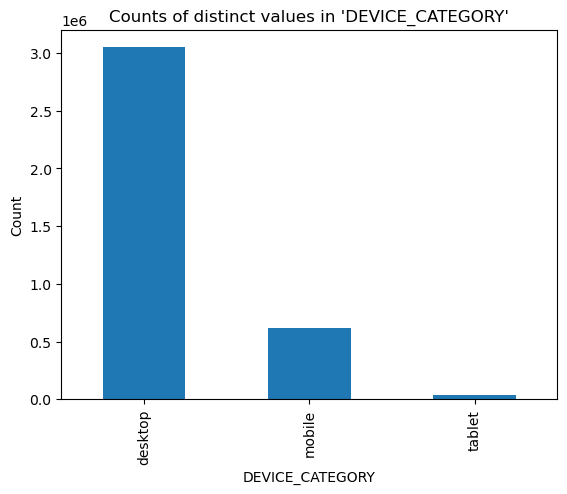

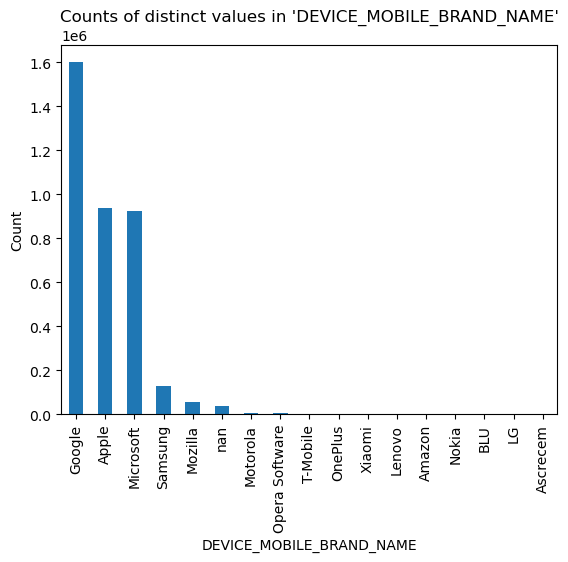

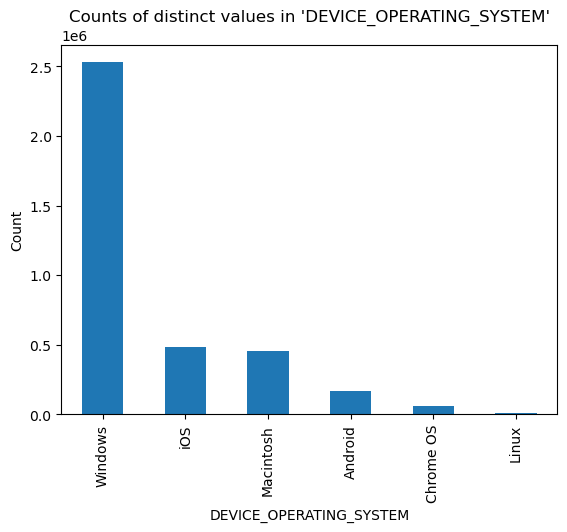

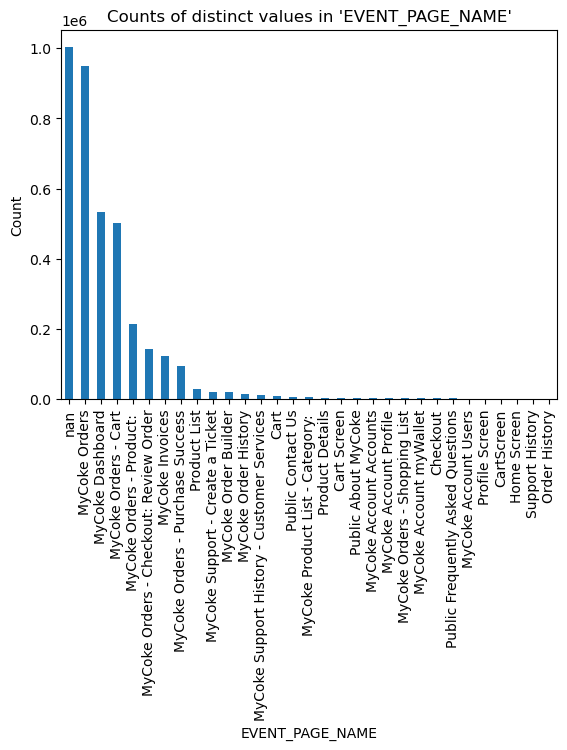

In [154]:
for col in GoogleAnalytics.columns[3:8]:
    value_counts = GoogleAnalytics[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [155]:
EventNameCounts = GoogleAnalytics["EVENT_NAME"].value_counts()
print(EventNameCounts)

EVENT_NAME
page_view                              1198482
button_click                            681917
view_item_list                          558466
update_cart                             215783
add_to_cart                             200580
                                        ...   
Ticket_CST_Displayed                         1
Delete_Order_History_Cache_Failed            1
Get_Decision_Tree_Data_Failed                1
Get_SnapPay_Mapping_MetaData_Failed          1
SSO_Token_Details_Failed                     1
Name: count, Length: 151, dtype: int64


I recommend we remove all distinct values besides the top ocurring in the dataframe. We should keep the following:

EVENT_Name:
1. page_view
2. button_click
3. view_item_list
4. update_cart
5. add_to_cart

For the rest of the columns, unless there is a 100% relationship between the distinct occurance of the severe minority class observations and cart abandonment, I think they should be removed. involvment in the model will require unecessary rebalancing/resampling. Therefore, we should only keep the following columns.  

DEVICE_CATEGORY:
1. desktop
2. mobile

DEVICE_MOBILE_BRAND_NAME:
1. Google
2. Apple
3. Microsoft
4. Samsung
5. Mozilla

DEVICE_OPERATING_SYSTEM:
1. Windows
2. iOS
3. Macintosh
4. Android

EVENT_PAGE_NAME:
1. MyCoke Orders
2. MyCoke Dashboard
3. MyCoke Orders - Cart
4. MyCoke Orders - Product
5. MyCoke Orders - Checkout: Review Order
6. MyCoke Invoices
7. MyCoke Orders - Purchase Success
8. Product List
9. MyCoke Support - Create Ticket
10. MyCoke Order Builder
11. MyCoke Order History
12. MyCoke Support History - Customer Services
13. Cart

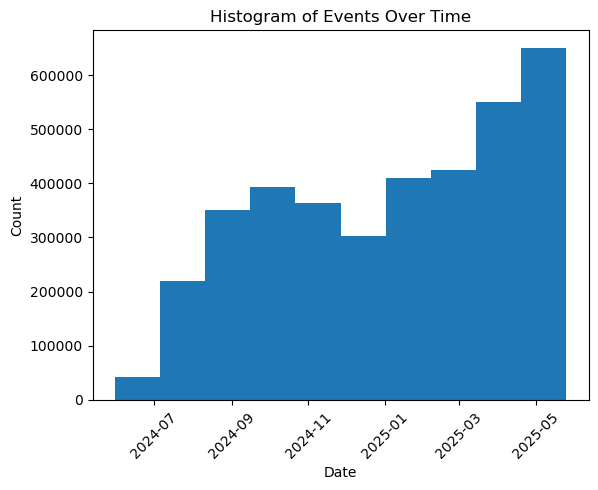

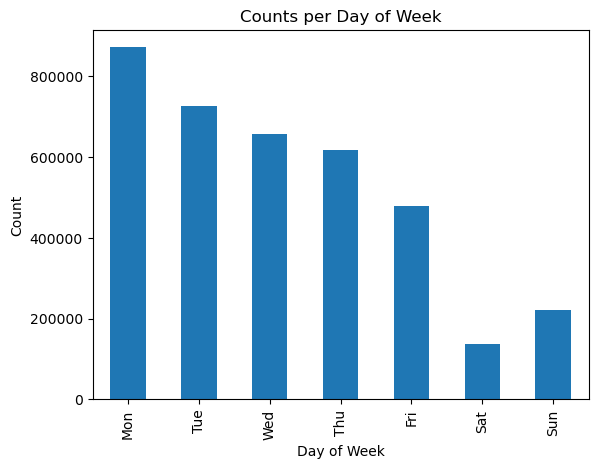

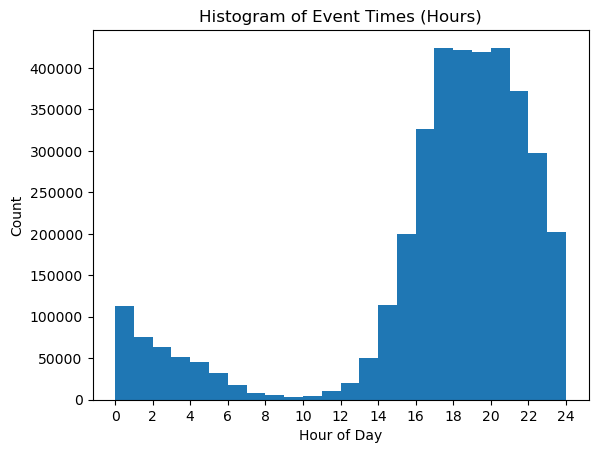

In [157]:
# Histogram showing activity over time
plt.hist(GoogleAnalytics["EVENT_DATE"], bins=10)  # choose number of bins (e.g., 6)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Histogram of Events Over Time")
plt.xticks(rotation=45)
plt.show()

# Bar chart showing activity by day of the week
GoogleAnalytics["day_of_week"] = GoogleAnalytics["EVENT_DATE"].dt.dayofweek
day_name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
GoogleAnalytics["day_of_week_name"] = GoogleAnalytics["day_of_week"].map(day_name_map)
day_counts = GoogleAnalytics["day_of_week_name"].value_counts().reindex(day_name_map.values(), fill_value=0)
day_counts.plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.title("Counts per Day of Week")
plt.show()

# Histogram showing activity by hour of the day
GoogleAnalytics["hour_of_day"] = GoogleAnalytics["EVENT_TIMESTAMP"].dt.hour + GoogleAnalytics["EVENT_TIMESTAMP"].dt.minute / 60
plt.hist(GoogleAnalytics["hour_of_day"], bins=24, range=(0, 24))  # 24 bins, 0-24 hours
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.title("Histogram of Event Times (Hours)")
plt.xticks(range(0, 25, 2))  # Show labels every 2 hours
plt.show()

For the timelines of these events. We can infer the following insights:
1. Usage of the google analytics platform has steadily increased over time.
2. Plateau in usage observed from Sept 2024 to Mar 2025. Roughly 6-month timeframe
3. Analytics are observed over a 12-month timeframe
4. Website activity is highest during the work week.
5. Usage decreases over the course of the week.
6. Most activity on the platform is from 2pm to 1am.
7. 4pm to midnight seem to be the peak.

### Orders

*Placeholder for writeup*

In [161]:
orders.head(n=5)

,CUSTOMER_ID,CREATED_DATE_EST,CREATED_DATE_UTC,MATERIAL_ID,ORDER_QUANTITY,ORDER_TYPE,PLANT_ID
0,600265510,2025-01-10,2025-01-10T22:40:25.000Z,152965.0,1.0,CALL CENTER,G267
1,600584506,2024-11-22,2024-11-22T17:34:30.000Z,156127.0,1.0,SALES REP,G221
2,600686120,2024-06-04,2024-06-05T00:29:33.000Z,103886.0,1.0,SALES REP,G291
3,501087671,2024-12-03,2024-12-03T18:14:23.000Z,134926.0,2.0,SALES REP,G163
4,501680332,2025-03-31,2025-03-31T22:33:07.000Z,152196.0,1.0,SALES REP,G221


In [162]:
print("There are",orders.index.size,"rows in the dataframe.")
print("There are",orders.columns.size,"columns in the dataframe.")

There are 1662157 rows in the dataframe.
There are 7 columns in the dataframe.


In [163]:
orders.dtypes

CUSTOMER_ID           int64
CREATED_DATE_EST     object
CREATED_DATE_UTC     object
MATERIAL_ID         float64
ORDER_QUANTITY      float64
ORDER_TYPE           object
PLANT_ID             object
dtype: object

It looks like we need to convert a few columns into their proper datatypes. Following columns that should be converted:

1. CREATED_DATE_EST -> date
2. CREATED_DATE_UTC -> datetime

In [165]:
# Convert the date/datetime(s)

orders['CREATED_DATE_EST'] = pd.to_datetime(orders['CREATED_DATE_EST'])
orders['CREATED_DATE_UTC'] = pd.to_datetime(orders['CREATED_DATE_UTC'])

# Check
print(orders.dtypes)

CUSTOMER_ID                       int64
CREATED_DATE_EST         datetime64[ns]
CREATED_DATE_UTC    datetime64[ns, UTC]
MATERIAL_ID                     float64
ORDER_QUANTITY                  float64
ORDER_TYPE                       object
PLANT_ID                         object
dtype: object


In [166]:
for col in orders.columns[0:7]:
    value_counts = orders[col].nunique()
    print(f"Counts of distinct values in '{col}'",value_counts)

Counts of distinct values in 'CUSTOMER_ID' 6166
Counts of distinct values in 'CREATED_DATE_EST' 359
Counts of distinct values in 'CREATED_DATE_UTC' 112390
Counts of distinct values in 'MATERIAL_ID' 1095
Counts of distinct values in 'ORDER_QUANTITY' 196
Counts of distinct values in 'ORDER_TYPE' 6
Counts of distinct values in 'PLANT_ID' 44


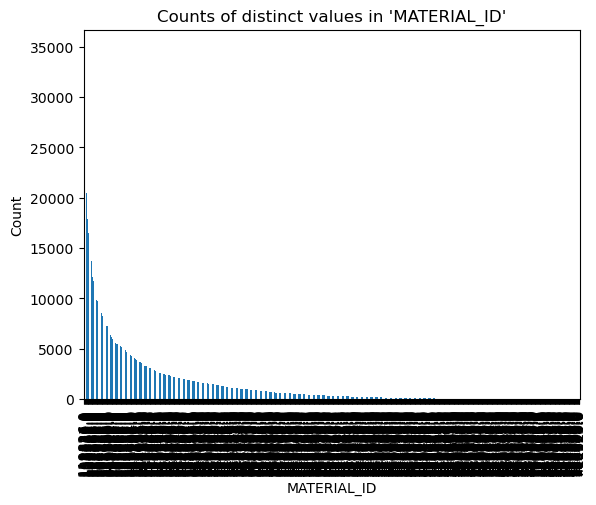

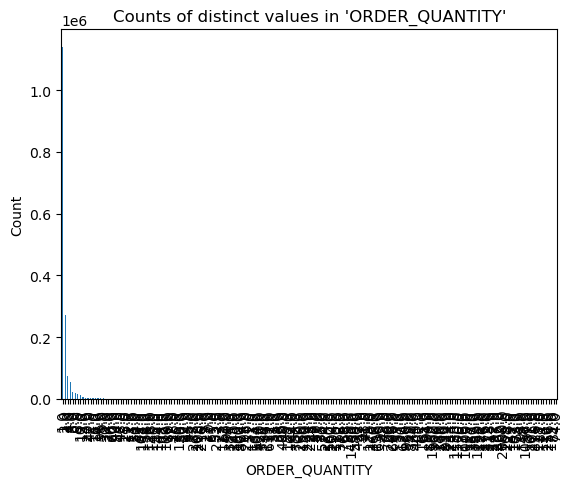

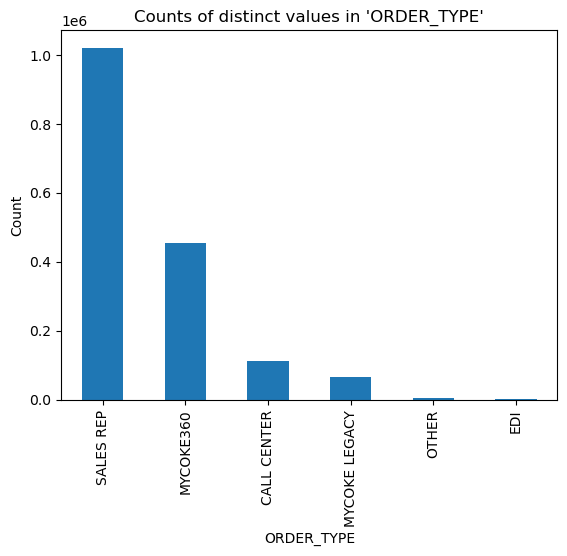

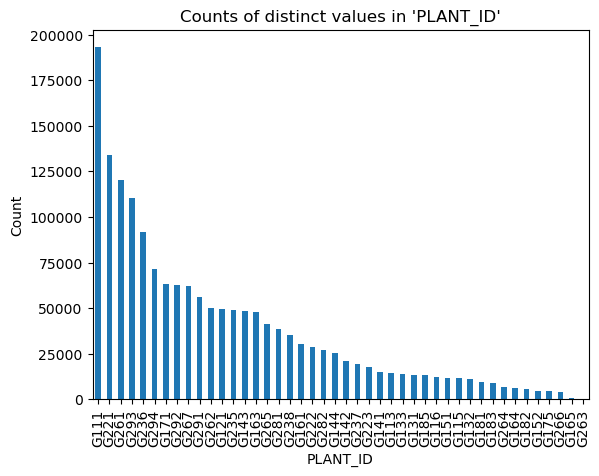

In [167]:
for col in orders.columns[3:7]:
    value_counts = orders[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

I recommend we remove all distinct values besides the top ocurring in the dataframe. We should keep the following:

ORDER_TYPE:
1. SALES REP
2. MYCOKE360
3. CALL CENTER
4. MYCOKE LEGACY

For the MaterialID column, we should create a threshold of count to only keep the material IDs that show up 1000 or more times, as those are the most important ones to focus on. 

For the ORDER_QUANTITY column, we should create some thresholds and group the quntities into buckets, similar to how you would a histogram. Order quantity could be linked to cart abandonment, so we want to keep as much of this data in the model.

For PlantID we should only include plants with a count of 10,000 in the model. Unless the models are being broken up by plant, then we can keep them all in. But we want to focus on plants with higher activity.

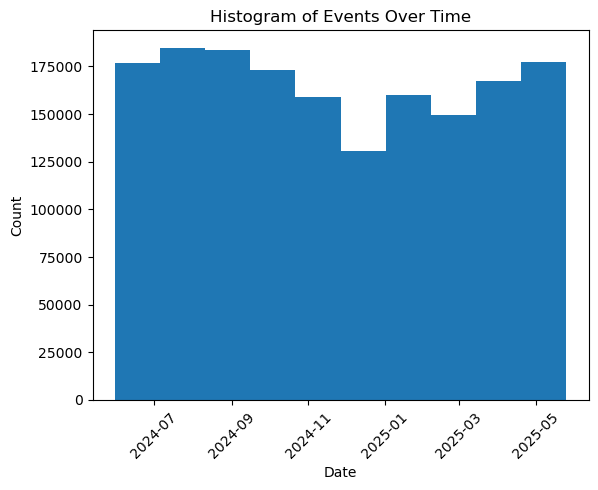

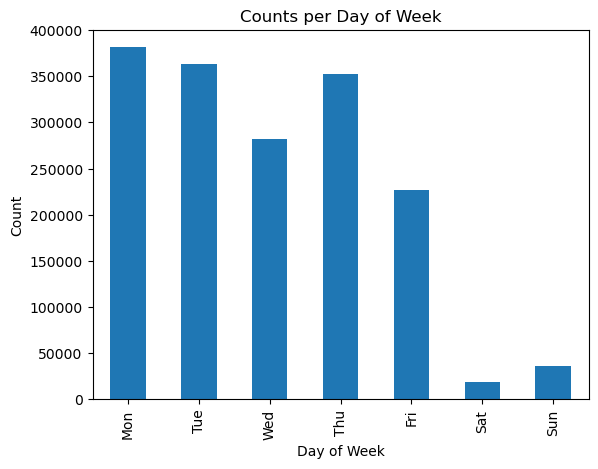

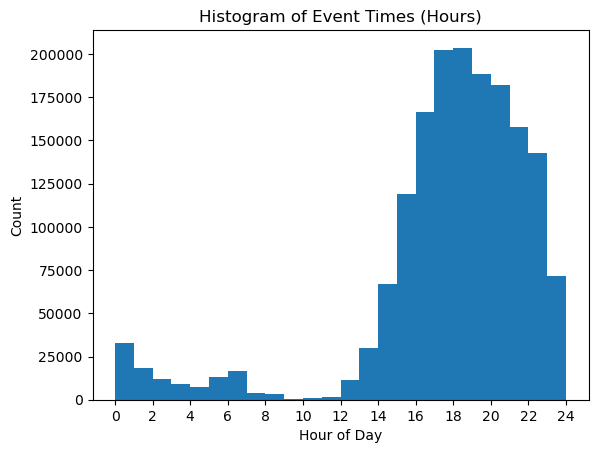

In [169]:
# Histogram showing activity over time
plt.hist(orders["CREATED_DATE_EST"], bins=10)  # choose number of bins (e.g., 6)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Histogram of Events Over Time")
plt.xticks(rotation=45)
plt.show()

# Bar chart showing activity by day of the week
orders["day_of_week"] = orders["CREATED_DATE_EST"].dt.dayofweek
day_name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
orders["day_of_week_name"] = orders["day_of_week"].map(day_name_map)
day_counts = orders["day_of_week_name"].value_counts().reindex(day_name_map.values(), fill_value=0)
day_counts.plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.title("Counts per Day of Week")
plt.show()

# Histogram showing activity by hour of the day
orders["hour_of_day"] = orders["CREATED_DATE_UTC"].dt.hour + orders["CREATED_DATE_UTC"].dt.minute / 60
plt.hist(orders["hour_of_day"], bins=24, range=(0, 24))  # 24 bins, 0-24 hours
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.title("Histogram of Event Times (Hours)")
plt.xticks(range(0, 25, 2))  # Show labels every 2 hours
plt.show()

For the timelines of these events. We can infer the following insights:
1. Orders remained somewhat steady (with a slight dip around Dec 2024) for Swire. This shows that the MyCoke360 platform gained adoption, but did not effect total order volume for Swire.
2. Orders are almost always placed on weekdays.
3. Orders are highest on Mon, Tues, and Thurs.
4. Analytics are observed over a 12-month timeframe
7. Most activity on the platform is from 2pm to 1am.
8. 4pm to midnight seem to be the peak.

### sales

*Placeholder for writeup*

In [173]:
sales.head(n=5)

,CUSTOMER_ID,POSTING_DATE,MATERIAL_ID,GROSS_PROFIT_DEAD_NET,PHYSICAL_VOLUME,NSI_DEAD_NET
0,600055574,7/17/2024,144775,130.68,22.0,737.00
1,600055574,7/17/2024,156082,37.42,6.0,105.42
2,501438989,7/17/2024,144775,41.84,4.0,166.40
3,600055574,7/17/2024,154914,53.24,4.0,123.88
4,600055574,7/17/2024,156182,110.30,10.0,348.80


In [174]:
print("There are",sales.index.size,"rows in the dataframe.")
print("There are",sales.columns.size,"columns in the dataframe.")

There are 499787 rows in the dataframe.
There are 6 columns in the dataframe.


There appear to be just under 500,000 instances of a sale over the 1-year period. This is good context for modeling.

In [176]:
sales.dtypes

CUSTOMER_ID                int64
POSTING_DATE              object
MATERIAL_ID                int64
GROSS_PROFIT_DEAD_NET    float64
PHYSICAL_VOLUME          float64
NSI_DEAD_NET             float64
dtype: object

There is only one column that needs to be converted to a date. POSTING_DATE

In [178]:
# Convert the date/datetime(s)

sales['POSTING_DATE'] = pd.to_datetime(sales['POSTING_DATE'])

# Check
print(sales.dtypes)

CUSTOMER_ID                       int64
POSTING_DATE             datetime64[ns]
MATERIAL_ID                       int64
GROSS_PROFIT_DEAD_NET           float64
PHYSICAL_VOLUME                 float64
NSI_DEAD_NET                    float64
dtype: object


In [179]:
for col in sales.columns[0:6]:
    value_counts = sales[col].nunique()
    print(f"Counts of distinct values in '{col}'",value_counts)

Counts of distinct values in 'CUSTOMER_ID' 5820
Counts of distinct values in 'POSTING_DATE' 313
Counts of distinct values in 'MATERIAL_ID' 961
Counts of distinct values in 'GROSS_PROFIT_DEAD_NET' 26107
Counts of distinct values in 'PHYSICAL_VOLUME' 239
Counts of distinct values in 'NSI_DEAD_NET' 16036


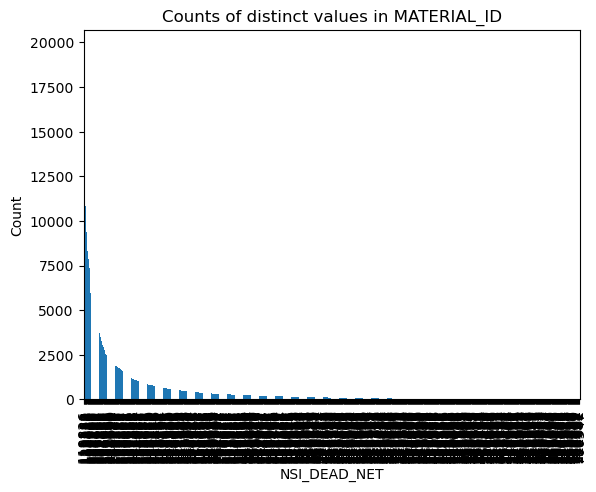

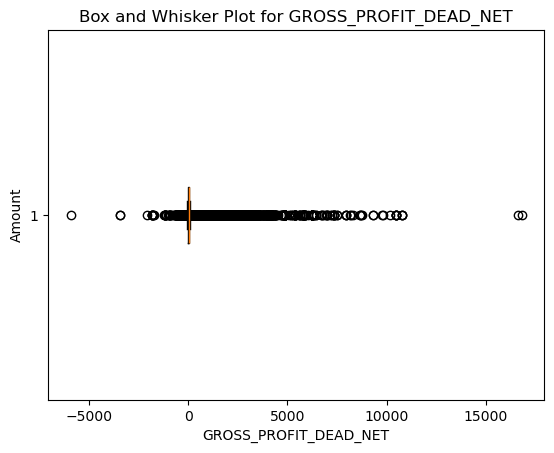

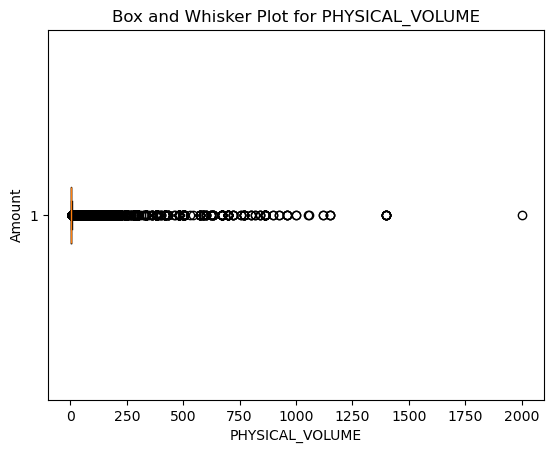

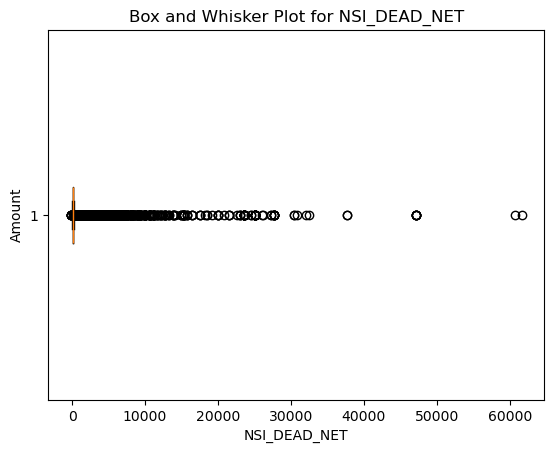

In [180]:
value_counts = sales["MATERIAL_ID"].value_counts()
# Plot each column’s value counts
value_counts.plot(kind="bar")
plt.title("Counts of distinct values in MATERIAL_ID")
plt.xlabel(col)
plt.ylabel("Count")
plt.show()


for col in sales.columns[3:6]:
    plt.boxplot(sales[col].dropna(), vert=False)  # dropna() to avoid issues with NaN values
    plt.xlabel(col)  # label with the column name
    plt.ylabel("Amount")
    plt.title(f"Box and Whisker Plot for {col}")
    plt.show()


For the MaterialID column, we should create a threshold of count to only keep the material IDs that show up 1000 or more times, as those are the most important ones to focus on. 

For the PHYSICAL_VOLUME and NSI_DEAD_NET columns, we should run a two-tailed Grubb's test to trim out outliers. For the GROSS_PROFIT_DEAD_NET column we should run a one-tailed Grubbs test to trim outliers.

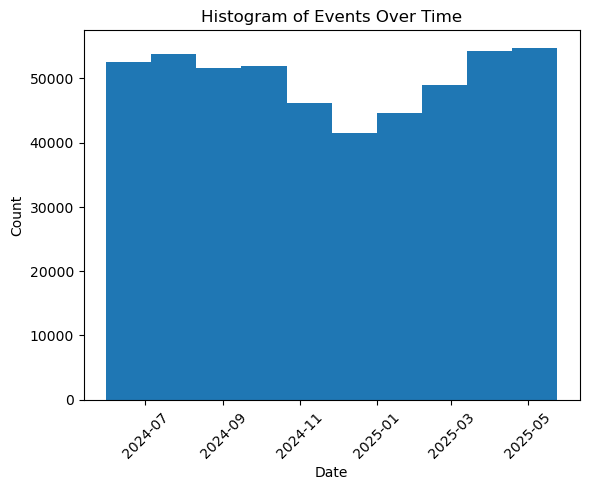

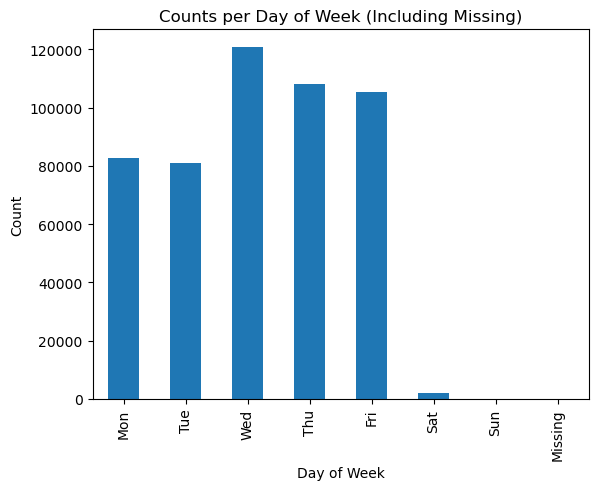

In [182]:
# Histogram showing activity over time
plt.hist(sales["POSTING_DATE"], bins=10)  # choose number of bins (e.g., 6)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Histogram of Events Over Time")
plt.xticks(rotation=45)
plt.show()

# show the counts of sales by day of week
sales["day_of_week"] = sales["POSTING_DATE"].dt.dayofweek
day_name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
sales["day_of_week_name"] = sales["day_of_week"].map(day_name_map).fillna("Missing")
day_counts = sales["day_of_week_name"].value_counts().reindex(
    list(day_name_map.values()) + ["Missing"],
    fill_value=0
)
day_counts.plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.title("Counts per Day of Week (Including Missing)")
plt.show()

Clearly, Mon-Fri is when sales occur, with little to no activity on Sat and Sun. There are also a new rows with NaNs, which should be removed from the dataset.

### material

*placeholder for writeup*

In [186]:
material.head(n=5)

,MATERIAL_ID,PACK_TYPE_DESC,TRADE_MARK_DESC,FLAVOUR_DESC,PACK_SIZE_DESC,BEV_CAT_DESC
0,125522,Plastic Bottle - Other,Oliver Originals,Salted Caramel,20 OZ,CORE SPARKLING
1,116974,Styrofoam Lid,Sunny Sip,Passionfruit,24 OZ,NaN
2,113144,Bag-In-Box,Sam's,Bubblegum,2.5 GALLON,JUICES/NECTARS
3,410256,Aluminum Can,Jack's Juices,Cappuccino,12 OZ,CORE SPARKLING
4,146980,Aluminum Can,Oliver Originals,Vanilla Latte,16 OZ,CORE SPARKLING


In [187]:
print("There are",material.index.size,"rows in the dataframe.")
print("There are",material.columns.size,"columns in the dataframe.")

There are 1252 rows in the dataframe.
There are 6 columns in the dataframe.


In [188]:
material.dtypes

MATERIAL_ID         int64
PACK_TYPE_DESC     object
TRADE_MARK_DESC    object
FLAVOUR_DESC       object
PACK_SIZE_DESC     object
BEV_CAT_DESC       object
dtype: object

No columns need to be converted.

In [190]:
for col in material.columns[0:6]:
    value_counts = material[col].nunique()
    print(f"Counts of distinct values in '{col}'",value_counts)

Counts of distinct values in 'MATERIAL_ID' 1252
Counts of distinct values in 'PACK_TYPE_DESC' 20
Counts of distinct values in 'TRADE_MARK_DESC' 14
Counts of distinct values in 'FLAVOUR_DESC' 172
Counts of distinct values in 'PACK_SIZE_DESC' 59
Counts of distinct values in 'BEV_CAT_DESC' 11


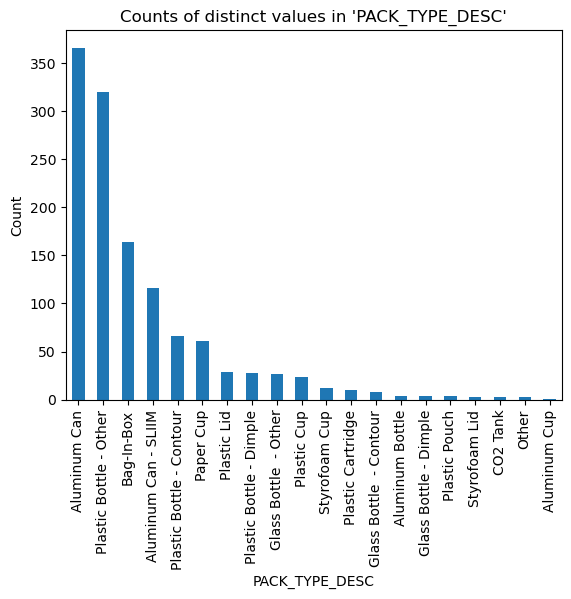

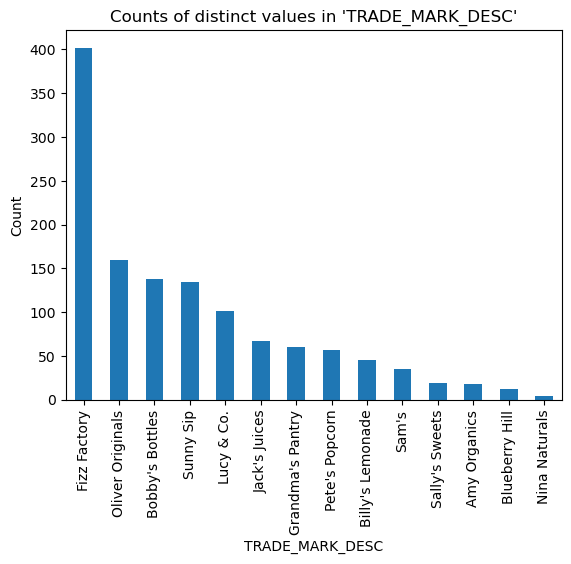

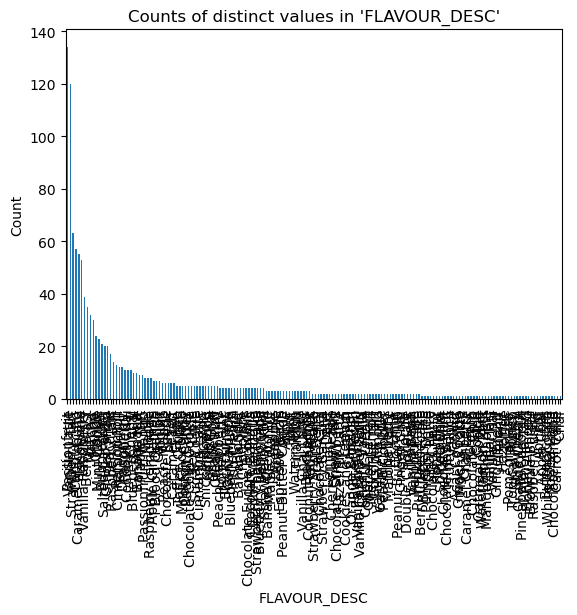

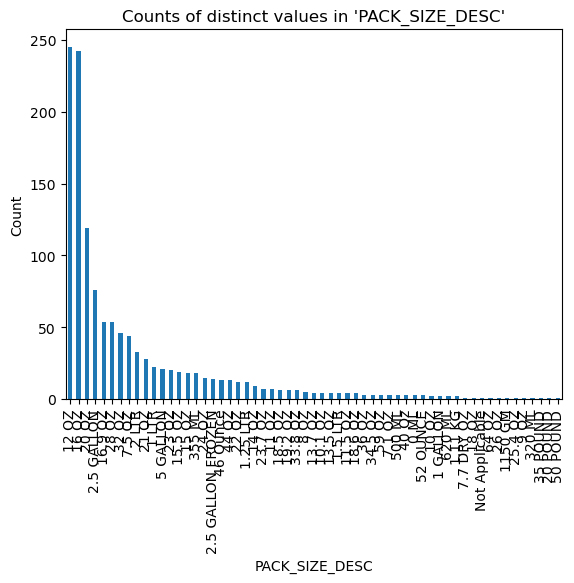

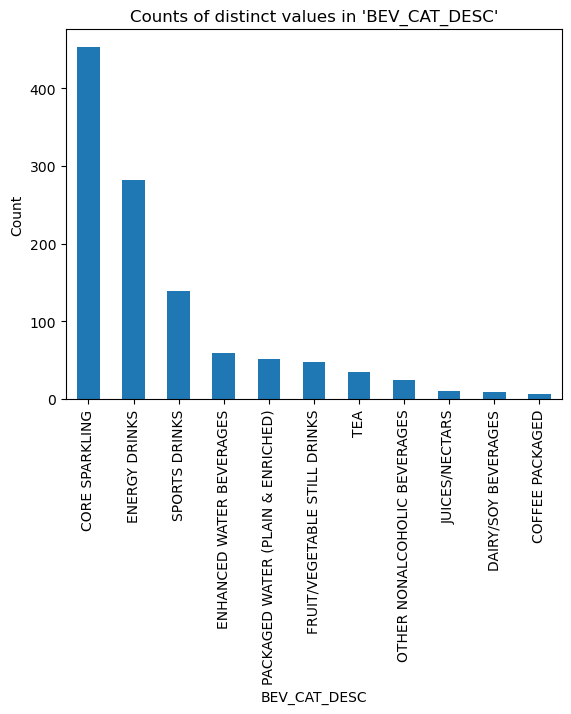

In [191]:
for col in material.columns[1:6]:
    value_counts = material[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Customer 

*placeholder for writeup*

In [194]:
customer.head(n=5)

,SALES_OFFICE,CUSTOMER_NUMBER,SALES_OFFICE_DESCRIPTION,DISTRIBUTION_MODE_DESCRIPTION,SHIPPING_CONDITIONS_DESCRIPTION,COLD_DRINK_CHANNEL_DESCRIPTION,CUSTOMER_SUB_TRADE_CHANNEL_DESCRIPTION
0,G111,500964906,"Draper, UT",Sideload,48 Hours,Restaurant,Dining
1,G111,501543906,"Draper, UT",Sideload,48 Hours,Restaurant,Mexican Fast Food
2,G293,501394111,"Tacoma, WA",OFS,24 Hours,Attraction,Recreation Center
3,G238,501528559,"Colorado Springs, CO",OFS,48 Hours,Attraction,Recreation Center
4,G132,500504789,"Alamosa, CO",OFS,48 Hours,Restaurant,Fast Food


In [195]:
print("There are",customer.index.size,"rows in the dataframe.")
print("There are",customer.columns.size,"columns in the dataframe.")

There are 6334 rows in the dataframe.
There are 7 columns in the dataframe.


In [196]:
customer.dtypes

SALES_OFFICE                              object
CUSTOMER_NUMBER                            int64
SALES_OFFICE_DESCRIPTION                  object
DISTRIBUTION_MODE_DESCRIPTION             object
SHIPPING_CONDITIONS_DESCRIPTION           object
COLD_DRINK_CHANNEL_DESCRIPTION            object
CUSTOMER_SUB_TRADE_CHANNEL_DESCRIPTION    object
dtype: object

It doesn't look like any columns need to have their datatypes changed. I will say though, it may be a good idea to check that CUSTOMER_NUMBER and CUSTOMER_ID all line up...

In [198]:
for col in customer.columns[0:6]:
    value_counts = customer[col].nunique()
    print(f"Counts of distinct values in '{col}'",value_counts)

Counts of distinct values in 'SALES_OFFICE' 44
Counts of distinct values in 'CUSTOMER_NUMBER' 6334
Counts of distinct values in 'SALES_OFFICE_DESCRIPTION' 44
Counts of distinct values in 'DISTRIBUTION_MODE_DESCRIPTION' 10
Counts of distinct values in 'SHIPPING_CONDITIONS_DESCRIPTION' 5
Counts of distinct values in 'COLD_DRINK_CHANNEL_DESCRIPTION' 9


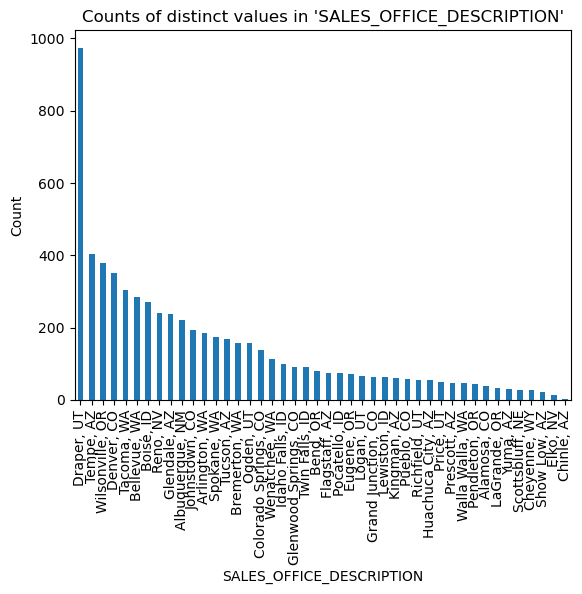

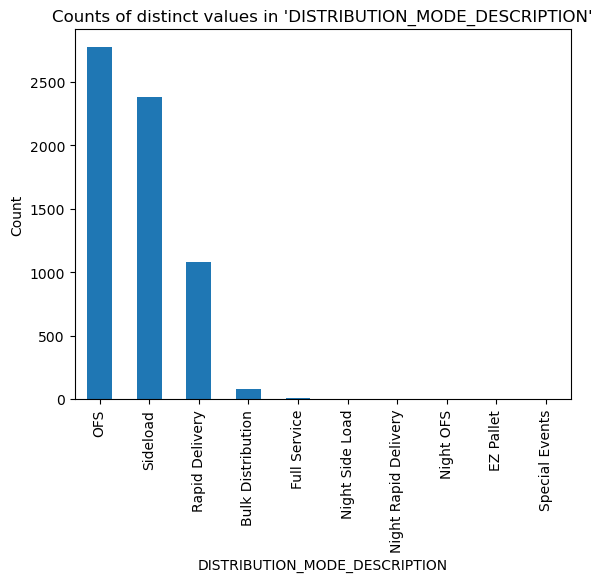

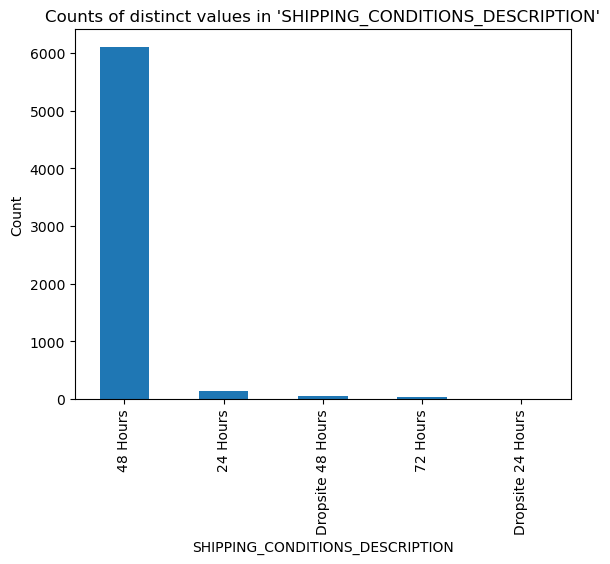

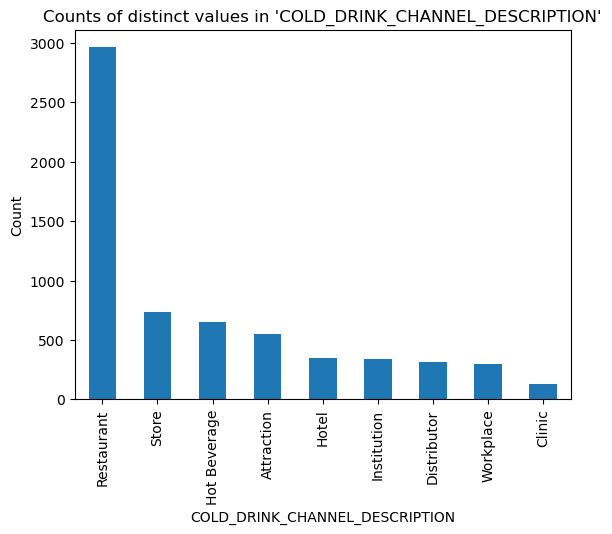

In [199]:
for col in customer.columns[2:6]:
    value_counts = customer[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

I recommend we remove all distinct values besides the top ocurring in the dataframe. We should keep the following:

DISTRIBUTION_MODE_DESCRIPTION:
1. OFS
2. SIDELOAD
3. RAPID DELIVERY

SHIPPING_CONDITIONS_DESCRIPTION:
1. 48 HOURS

COLD_DRINK_CHANNEL_DESCRIPTION:
1. All except clinic

For the SALES_OFFICE_DESCRIPTION column, I recommend we remove the smallest 10 to 15 stores as to focus on the larger markets.

### cutoff_times

*placeholder for writeup*

In [203]:
cutoff_times.head(n=5)

,SALES_OFFICE,PLANT_ID,CUTOFFTIME__C,SHIPPING_CONDITION_TIME,DISTRIBUTION_MODE
0,"Draper, UT",G111,6:00:00 PM,72hrs,Tell Sell
1,"Draper, UT",G111,6:00:00 PM,48hrs,Tell Sell
2,"Draper, UT",G111,1:30:00 PM,24hrs,Tell Sell
3,"Draper, UT",G111,3:30:00 PM,24hrs,OFS
4,"Draper, UT",G111,3:30:00 PM,24hrs,Bulk Distribution


In [204]:
print("There are",cutoff_times.index.size,"rows in the dataframe.")
print("There are",cutoff_times.columns.size,"columns in the dataframe.")

There are 220 rows in the dataframe.
There are 5 columns in the dataframe.


In [205]:
cutoff_times.dtypes

SALES_OFFICE               object
PLANT_ID                   object
CUTOFFTIME__C              object
SHIPPING_CONDITION_TIME    object
DISTRIBUTION_MODE          object
dtype: object

There is only one column that needs to be converted to a date. POSTING_DATE

In [207]:
# Convert the date/datetime(s)

cutoff_times['CUTOFFTIME__C'] = pd.to_datetime(
    cutoff_times['CUTOFFTIME__C'],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"             
)

# Check
print(cutoff_times.dtypes)

SALES_OFFICE                       object
PLANT_ID                           object
CUTOFFTIME__C              datetime64[ns]
SHIPPING_CONDITION_TIME            object
DISTRIBUTION_MODE                  object
dtype: object


In [208]:
for col in cutoff_times.columns[0:6]:
    value_counts = cutoff_times[col].nunique()
    print(f"Counts of distinct values in '{col}'",value_counts)

Counts of distinct values in 'SALES_OFFICE' 43
Counts of distinct values in 'PLANT_ID' 43
Counts of distinct values in 'CUTOFFTIME__C' 0
Counts of distinct values in 'SHIPPING_CONDITION_TIME' 3
Counts of distinct values in 'DISTRIBUTION_MODE' 12


IndexError: index 0 is out of bounds for axis 0 with size 0

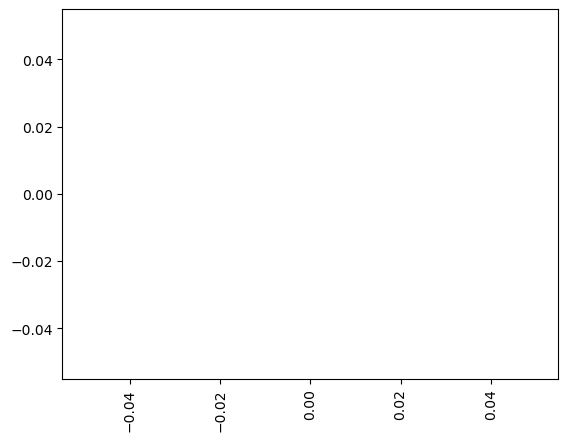

In [209]:
for col in cutoff_times.columns[2:5]:
    value_counts = cutoff_times[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

I recommend we remove all distinct values besides the top ocurring in the dataframe. We should keep the following:

SHIPPING_CONDITION_TIME:
1. 24hrs
2. 48hrs

DISTRIBTUION MODE:
1. OFS
2. Sideload
3. Bulk Distribution
4. Full Service
5. Rapid Delivery
6. Night Rapid Delivery

In [ ]:
# Histogram showing activity by hour of the day
cutoff_times["hour_of_day"] = cutoff_times["CUTOFFTIME__C"].dt.hour + cutoff_times["CUTOFFTIME__C"].dt.minute / 60
plt.hist(cutoff_times["hour_of_day"], bins=24, range=(0, 24))  # 24 bins, 0-24 hours
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.title("Histogram of Event Times (Hours)")
plt.xticks(range(0, 25, 2))  # Show labels every 2 hours
plt.show()

Cutoff times are clearly between 10am and 5pm. We should cut out cutoff times outside this range. 

### operating_hours

*placeholder for writeup*

In [ ]:
operating_hours.head(n=5)

In [ ]:
print("There are",operating_hours.index.size,"rows in the dataframe.")
print("There are",operating_hours.columns.size,"columns in the dataframe.")

In [ ]:
operating_hours.dtypes

Looks like we need to change the anchor date datatype to datetime.

In [ ]:
# Convert the date/datetime(s)

operating_hours['CALLING_ANCHOR_DATE'] = pd.to_datetime(operating_hours['CALLING_ANCHOR_DATE'])

# Check
print(operating_hours.dtypes)

In [ ]:
for col in operating_hours.columns[1:3]:
    value_counts = operating_hours[col].value_counts()
    # Plot each column’s value counts
    value_counts.plot(kind="bar")
    plt.title(f"Counts of distinct values in '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

FREQUENCY - We can see from the output above that we can drop "Every 3 weeks" during the modelling. We should focus on common anchor dates.

DELIVERY_ANCHOR_DAY - We should remove Sunday and error from the table and focus on customers with delivery anchor dates on Mon-Fri

### Visit Plan

placeholder for table write-up/summary

In [ ]:
visit_plan.head(n=5)

In [ ]:
print("There are",visit_plan.index.size,"rows in the dataframe.")
print("There are",visit_plan.columns.size,"columns in the dataframe.")

In [ ]:
visit_plan.dtypes

Looks like we ned to change the following variables to datetime:
1. ELT_TS
2. SNAPSHOT_DATE
3. ANCHOR_DATE

We may need to turn the following into an INT if need be (for modelling)...
1. FREQUENCY

In [ ]:
date_cols = ["ELT_TS", "SNAPSHOT_DATE", "ANCHOR_DATE"]

# 1) Parse with strict format and mark bad rows
bad_any = pd.Series(False, index=visit_plan.index)
for c in date_cols:
    s = pd.to_datetime(visit_plan[c], format="%Y-%m-%d", errors="coerce")
    bad = s.isna() & visit_plan[c].notna()   # failed to parse but not empty
    bad_any |= bad

# Optional: inspect what failed
# print(visit_plan.loc[bad_any, date_cols].head(10))

# 2) Drop bad rows
visit_plan = visit_plan.loc[~bad_any].copy().reset_index(drop=True)

# 3) Convert for real (now safe)
for c in date_cols:
    visit_plan[c] = pd.to_datetime(visit_plan[c], format="%Y-%m-%d", errors="raise")

print(visit_plan.dtypes)

In [ ]:
visit_plan.shape

We had to drop rows where the datetimes were not inputted properly. This resulted in <1000 rows being removed from the dataset.

Since the visit plan table is historical data, there is no need to filter out items to create the most material dataset. Once the previous items from the other dataset have been filtered out, the relevant items from this table will be brought in properly once joined.

## Step 4: Question Specific EDA

The questions that will be prepared for this section of the EDA are as follows:

1. What behavioral events or sequence of events are the strongest predictors of cart abandonment?
2. What behaviors or conditions lead to a customer returning to complete a previously abandoned cart?

First, we need to *define* cart abandonment and set up a way to *identify* it in the data. 

Definition of cart abandonment: In the context of our data, cart abandonment is defined a process following the steps below 
1. In the EVENT_NAME column of the google analytics dataset, 'added_to_cart' is created
2. No 'purchased' event is created by the nearest cutoff time from the CUTOFF_TIMES dataset.
3. Customer_ID is used to delineate which events correlate with the correct cutoff times

Therefore, we need to extract an "abandoned" dataset from the the originial dataset, showing when tables were abandoned vs not.

To identify material data, we will take the dimentionality reductions and datatype adjustments recommended above, to keep the analysis concise and material to a majority of Swire's operations. 